# **Import Libraries**

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Data**

In [83]:
df = pd.read_csv('./data/data.csv', encoding='ISO-8859-1')

# **Initial Data Inspection**

In [84]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# **Data Wrangling**

#### Data Check

In [85]:
# Missing Values
print("Missing Values:")
print(df.isnull().sum())
print("\nMissing Values (%):")
print((df.isnull().sum() / len(df) * 100).round(2))

# Data Types
print("\nData Types:")
print(df.dtypes)

# Duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing Values (%):
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Duplicate Rows: 5268


## Data Cleaning

In [86]:
# Remove Missing Values
df_clean = df.dropna(subset=['CustomerID', 'Description'])
print(f"Rows before cleaning: {len(df)}")
print(f"Rows after removing nulls: {len(df_clean)}")

# Remove Duplicate Rows
df_clean = df_clean.drop_duplicates()
print(f"Rows after removing duplicates: {len(df_clean)}")

# Convert InvoiceDate to DateTime Format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print(f"\nInvoiceDate dtype: {df_clean['InvoiceDate'].dtype}")

#Cleaning Results
print("\nMissing Values after cleaning:")
print(df_clean.isnull().sum())

# Check Abnormal Unit Price
print(df_clean[df_clean['UnitPrice'] < 0.01]['UnitPrice'].value_counts().head(10))
print(f"\nRows with UnitPrice < 0.01: {len(df_clean[df_clean['UnitPrice'] < 0.01])}")

# Remove rows with invalid UnitPrice (< £0.01)
before = len(df_clean)
df_clean = df_clean[df_clean['UnitPrice'] >= 0.01]
after = len(df_clean)

print(f"Rows removed (invalid UnitPrice): {before - after}")
print(f"Remaining rows: {after}")


Rows before cleaning: 541909
Rows after removing nulls: 406829
Rows after removing duplicates: 401604

InvoiceDate dtype: datetime64[ns]

Missing Values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
UnitPrice
0.000    40
0.001     4
Name: count, dtype: int64

Rows with UnitPrice < 0.01: 44
Rows removed (invalid UnitPrice): 44
Remaining rows: 401560


# **Add Calculated Columns**

In [87]:
# Total Sales per transaction
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Extract Month and Year from InvoiceDate
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Verify
print("New columns added:")
df_clean[['InvoiceDate', 'Quantity', 'UnitPrice', 'TotalSales', 'Year', 'Month', 'YearMonth']].head()


New columns added:


,InvoiceDate,Quantity,UnitPrice,TotalSales,Year,Month,YearMonth
0,2010-12-01 08:26:00,6,2.55,15.30,2010,12,2010-12
1,2010-12-01 08:26:00,6,3.39,20.34,2010,12,2010-12
2,2010-12-01 08:26:00,8,2.75,22.00,2010,12,2010-12
3,2010-12-01 08:26:00,6,3.39,20.34,2010,12,2010-12
4,2010-12-01 08:26:00,6,3.39,20.34,2010,12,2010-12


# **Exploratory Data Analysis (EDA)**

In [88]:
# Define non-product items to exclude
non_products = ['POSTAGE', 'CARRIAGE', 'MANUAL', 'DOTCOM POSTAGE', 
                'BANK CHARGES', 'Manual', 'CRUK Commission', 'Discount']

## Monthly Sales Trend

Monthly Sales Summary:
   YearMonth  TotalSales
0    2010-12   552372.86
1    2011-01   473731.90
2    2011-02   435534.07
3    2011-03   578576.21
4    2011-04   425222.67
5    2011-05   647011.67
6    2011-06   606862.52
7    2011-07   573112.32
8    2011-08   615078.09
9    2011-09   929356.23
10   2011-10   973306.38
11   2011-11  1126815.07
12   2011-12   341539.43


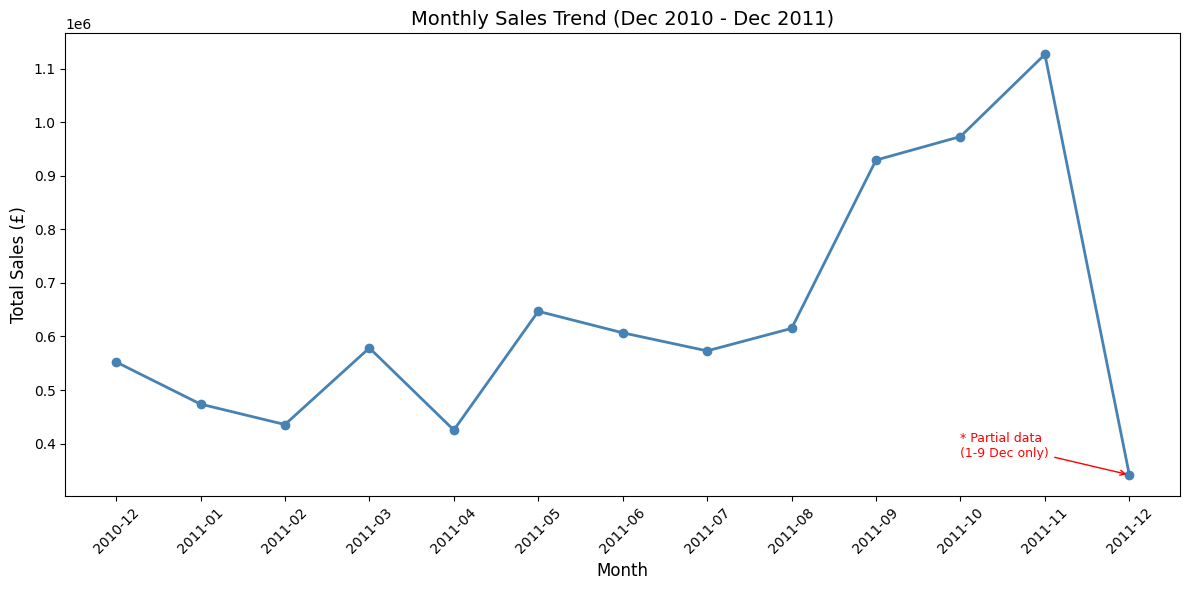

Dec 2011 date range:
From: 2011-12-01 08:12:00
To:   2011-12-09 12:50:00
Total transactions: 17382


In [89]:
# Monthly Sales Trend
monthly_sales = df_clean.groupby('YearMonth')['TotalSales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

print("Monthly Sales Summary:")
print(monthly_sales) 

# Plot Monthly Sales Trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['YearMonth'], monthly_sales['TotalSales'], 
         marker='o', linewidth=2, color='steelblue')

plt.title('Monthly Sales Trend (Dec 2010 - Dec 2011)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (£)', fontsize=12)
plt.xticks(rotation=45)

# Annotate Dec 2011 as partial data
last_idx = len(monthly_sales) - 1
plt.annotate('* Partial data\n(1-9 Dec only)',
             xy=(last_idx, monthly_sales['TotalSales'].iloc[-1]),
             xytext=(last_idx - 2, monthly_sales['TotalSales'].iloc[-1] * 1.1),
             fontsize=9, color='red',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('images/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Check Dec 2011 data range
dec_2011 = df_clean[df_clean['YearMonth'] == '2011-12']
print("Dec 2011 date range:")
print(f"From: {dec_2011['InvoiceDate'].min()}")
print(f"To:   {dec_2011['InvoiceDate'].max()}")
print(f"Total transactions: {len(dec_2011)}")

## Monthly Quantity vs Average Unit Price

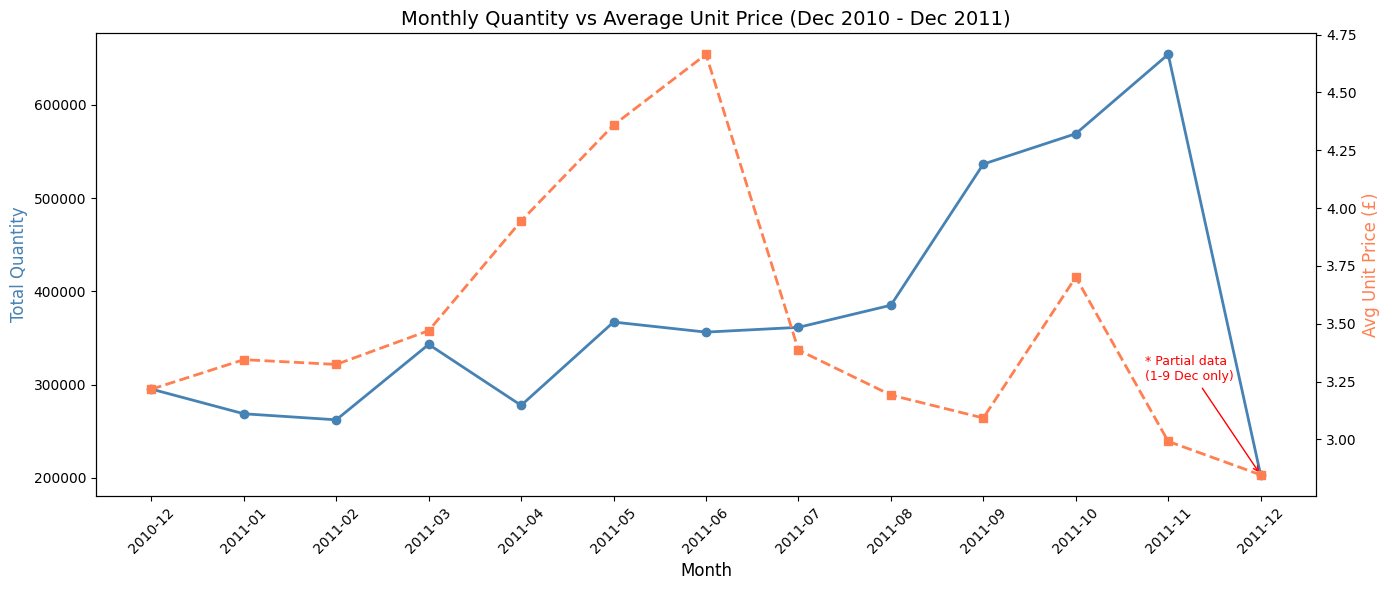

In [90]:
# Monthly Quantity vs Average Unit Price
monthly_analysis = df_clean.groupby('YearMonth').agg(
    Total_Quantity=('Quantity', 'sum'),
    Avg_UnitPrice=('UnitPrice', 'mean')
).reset_index()

monthly_analysis['YearMonth'] = monthly_analysis['YearMonth'].astype(str)

# Plot with dual Y axis
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(monthly_analysis['YearMonth'], monthly_analysis['Total_Quantity'],
         marker='o', color='steelblue', linewidth=2, label='Total Quantity')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Quantity', color='steelblue', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_analysis['YearMonth'], monthly_analysis['Avg_UnitPrice'],
         marker='s', color='coral', linewidth=2, linestyle='--', label='Avg Unit Price')
ax2.set_ylabel('Avg Unit Price (£)', color='coral', fontsize=12)

# annotation for Dec 2011
ax1.annotate('* Partial data\n(1-9 Dec only)',
             xy=(12, monthly_analysis['Total_Quantity'].iloc[-1]),
             xytext=(10.75, monthly_analysis['Total_Quantity'].iloc[-1] * 1.5),
             fontsize=9, color='red',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Monthly Quantity vs Average Unit Price (Dec 2010 - Dec 2011)', fontsize=14)
fig.tight_layout()
plt.show()

## Top 10 Products by Total Sales

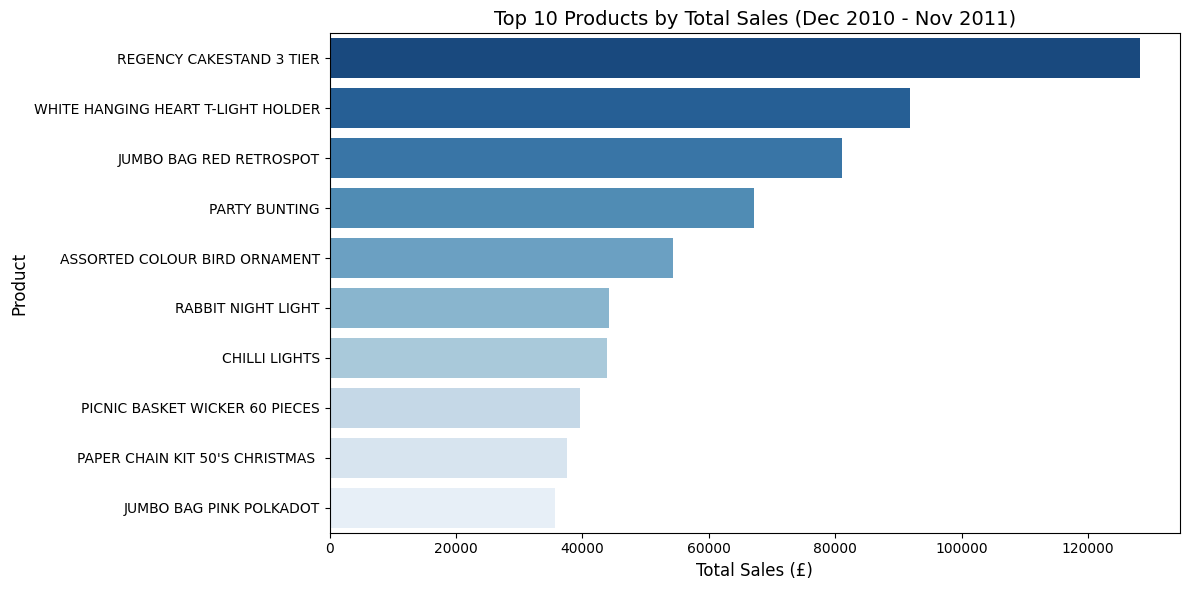


Top 10 Products:
                       Description  TotalSales
          REGENCY CAKESTAND 3 TIER   128139.37
WHITE HANGING HEART T-LIGHT HOLDER    91774.96
           JUMBO BAG RED RETROSPOT    81067.32
                     PARTY BUNTING    67163.13
     ASSORTED COLOUR BIRD ORNAMENT    54332.45
                RABBIT NIGHT LIGHT    44192.65
                     CHILLI LIGHTS    43804.74
    PICNIC BASKET WICKER 60 PIECES    39619.50
   PAPER CHAIN KIT 50'S CHRISTMAS     37570.26
           JUMBO BAG PINK POLKADOT    35635.36


In [91]:
# Top 10 Products by Total Sales
top_products = df_clean[
    (df_clean['YearMonth'] != '2011-12') & 
    (~df_clean['Description'].isin(non_products))
].groupby('Description')['TotalSales'].sum().reset_index()
top_products = top_products.sort_values('TotalSales', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, 
            x='TotalSales', 
            y='Description',
            hue='Description',
            palette='Blues_r',
            legend=False)

plt.title('Top 10 Products by Total Sales (Dec 2010 - Nov 2011)', fontsize=14)
plt.xlabel('Total Sales (£)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig('images/top10_products.png', dpi=150, bbox_inches='tight')
plt.show()

# Print exact numbers
print("\nTop 10 Products:")
print(top_products.to_string(index=False))

## Top 10 Countries by Total Sales

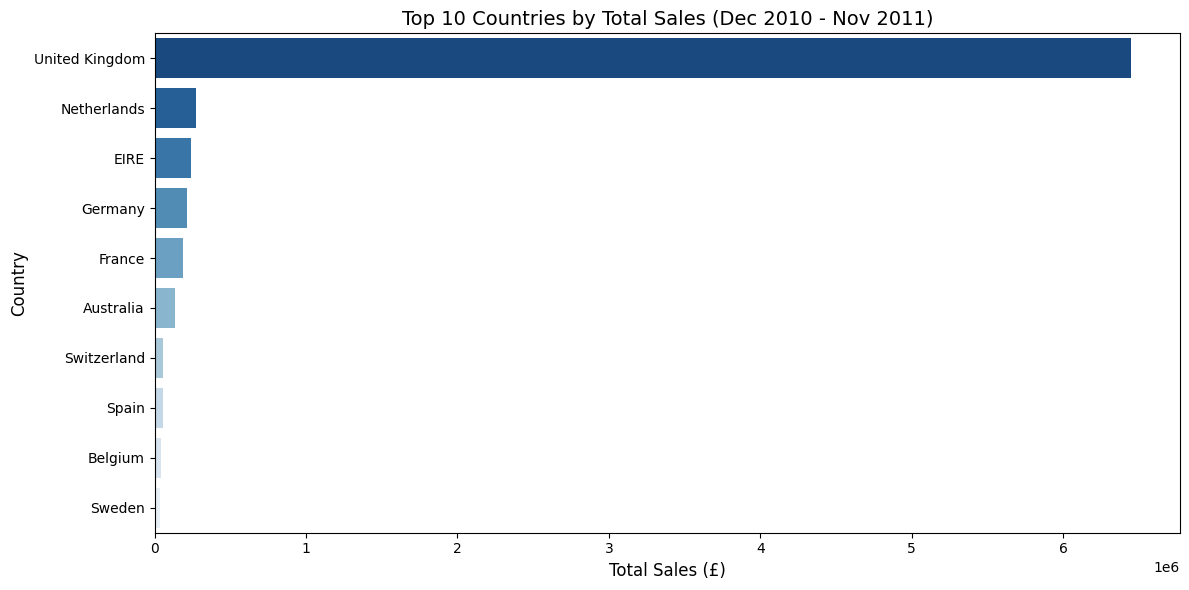


Top 10 Countries:
       Country  TotalSales
United Kingdom  6450202.63
   Netherlands   272933.52
          EIRE   243025.41
       Germany   213704.77
        France   189577.22
     Australia   137009.77
   Switzerland    55739.40
         Spain    54484.60
       Belgium    39501.53
        Sweden    36585.41


In [92]:
# Top 10 Countries by Total Sales
top_countries = df_clean[df_clean['YearMonth'] != '2011-12'].groupby('Country')['TotalSales'].sum().reset_index()
top_countries = top_countries.sort_values('TotalSales', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, 
            x='TotalSales', 
            y='Country',
            hue='Country',
            palette='Blues_r',
            legend=False)

plt.title('Top 10 Countries by Total Sales (Dec 2010 - Nov 2011)', fontsize=14)
plt.xlabel('Total Sales (£)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('images/top10_countries.png', dpi=150, bbox_inches='tight')
plt.show()

# Print exact numbers
print("\nTop 10 Countries:")
print(top_countries.to_string(index=False))

## International Markets (Excluding UK)

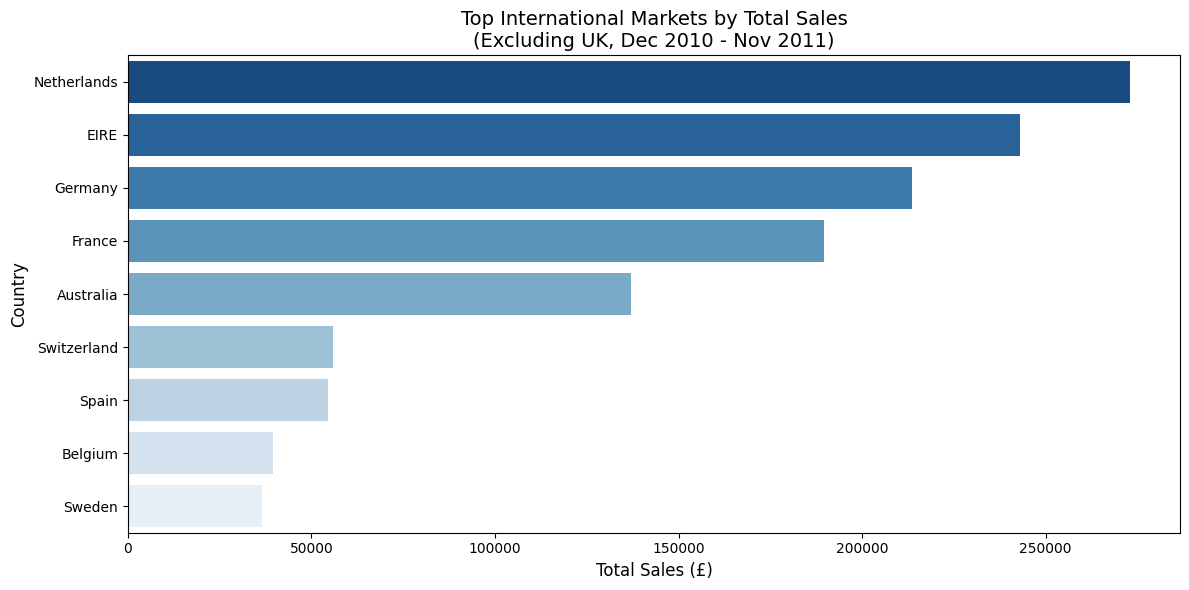

In [93]:
# International Markets (Excluding UK)
top_countries_ex_uk = df_clean[
    (df_clean['YearMonth'] != '2011-12') & 
    (df_clean['Country'] != 'United Kingdom')
].groupby('Country')['TotalSales'].sum().reset_index()

top_countries_ex_uk = top_countries_ex_uk.sort_values('TotalSales', ascending=False).head(9)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries_ex_uk,
            x='TotalSales',
            y='Country',
            hue='Country',
            palette='Blues_r',
            legend=False)

plt.title('Top International Markets by Total Sales\n(Excluding UK, Dec 2010 - Nov 2011)', fontsize=14)
plt.xlabel('Total Sales (£)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('images/International_Markets_Excluding_UK.png', dpi=150, bbox_inches='tight')
plt.show()

## Top Products by Country

In [94]:
# Top 3 Products for Top 10 Countries (excluding non-products)
top_products_by_country = df_clean[
    (df_clean['YearMonth'] != '2011-12') &
    (~df_clean['Description'].isin(non_products))
].groupby(['Country', 'Description'])['TotalSales'].sum().reset_index()

# Get top 3 products per country
top3_by_country = (top_products_by_country
    .sort_values('TotalSales', ascending=False)
    .groupby('Country')
    .head(3)
    .sort_values(['Country', 'TotalSales'], ascending=[True, False])
)

# Display Top 10 Countries only
top10_country_list = top_countries['Country'].tolist()
top3_filtered = top3_by_country[
    top3_by_country['Country'].isin(top10_country_list)
].copy()

# Print formatted table
for country in top10_country_list:
    country_data = top3_filtered[top3_filtered['Country'] == country]
    print(f"\n{'='*50}")
    print(f"  {country}")
    print(f"{'='*50}")
    for _, row in country_data.iterrows():
        print(f"  {row['Description']:<45} £{row['TotalSales']:>10,.2f}")


  United Kingdom
  REGENCY CAKESTAND 3 TIER                      £ 99,911.47
  WHITE HANGING HEART T-LIGHT HOLDER            £ 86,558.06
  JUMBO BAG RED RETROSPOT                       £ 73,386.59

  Netherlands
  ROUND SNACK BOXES SET OF4 WOODLAND            £  7,746.60
  SPACEBOY LUNCH BOX                            £  7,485.60
  RABBIT NIGHT LIGHT                            £  6,990.88

  EIRE
  REGENCY CAKESTAND 3 TIER                      £  6,722.70
  3 TIER CAKE TIN RED AND CREAM                 £  3,011.65
  JAM MAKING SET WITH JARS                      £  2,942.00

  Germany
  REGENCY CAKESTAND 3 TIER                      £  7,505.55
  ROUND SNACK BOXES SET OF4 WOODLAND            £  3,395.40
  ROUND SNACK BOXES SET OF 4 FRUITS             £  1,843.75

  France
  RABBIT NIGHT LIGHT                            £  6,722.16
  REGENCY CAKESTAND 3 TIER                      £  2,492.55
  RED TOADSTOOL LED NIGHT LIGHT                 £  2,049.30

  Australia
  RABBIT NIGHT LIGHT     

## Bottom 10 Products by Total Sales

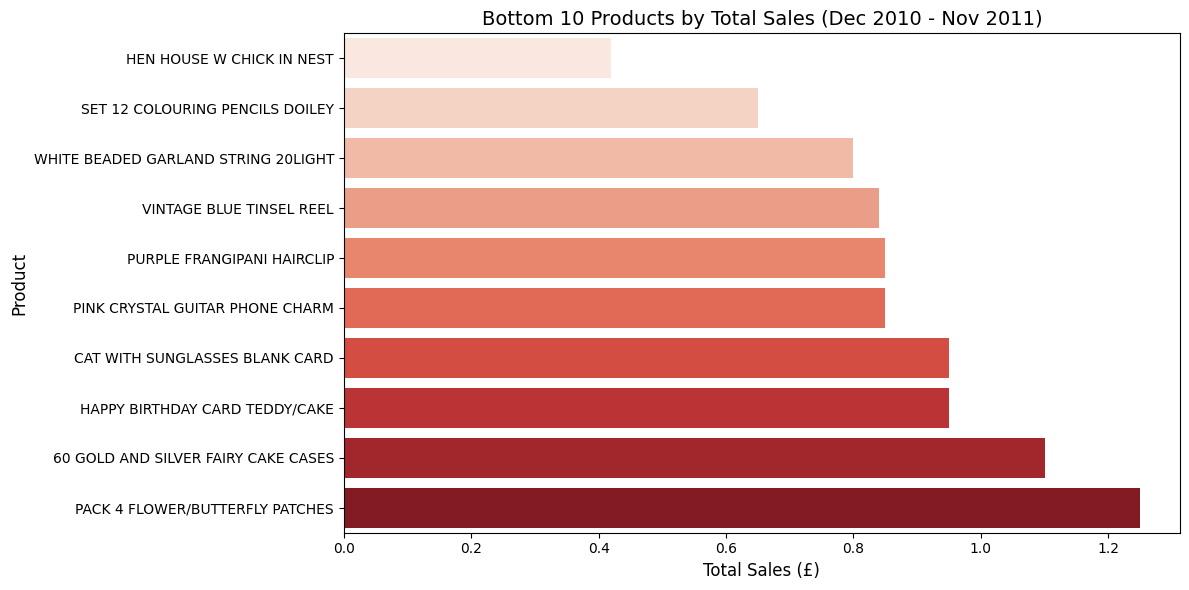


Bottom 10 Products:
                        Description  TotalSales
          HEN HOUSE W CHICK IN NEST        0.42
    SET 12 COLOURING PENCILS DOILEY        0.65
WHITE BEADED GARLAND STRING 20LIGHT        0.80
           VINTAGE BLUE TINSEL REEL        0.84
         PURPLE FRANGIPANI HAIRCLIP        0.85
    PINK CRYSTAL GUITAR PHONE CHARM        0.85
     CAT WITH SUNGLASSES BLANK CARD        0.95
     HAPPY BIRTHDAY CARD TEDDY/CAKE        0.95
60 GOLD AND SILVER FAIRY CAKE CASES        1.10
    PACK 4 FLOWER/BUTTERFLY PATCHES        1.25


In [95]:
# Bottom 10 Products by Total Sales
bottom_products = df_clean[
    (df_clean['YearMonth'] != '2011-12') &
    (~df_clean['Description'].isin(non_products))
].groupby('Description')['TotalSales'].sum().reset_index()

# Only keep positive sales, find lowest
bottom_products = bottom_products[bottom_products['TotalSales'] > 0]
bottom_products = bottom_products.sort_values('TotalSales', ascending=True).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=bottom_products,
            x='TotalSales',
            y='Description',
            hue='Description',
            palette='Reds',
            legend=False)

plt.title('Bottom 10 Products by Total Sales (Dec 2010 - Nov 2011)', fontsize=14)
plt.xlabel('Total Sales (£)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.show()

print("\nBottom 10 Products:")
print(bottom_products.to_string(index=False))

In [96]:
# Investigate bottom products
bottom_list = bottom_products['Description'].tolist()

investigation = df_clean[
    df_clean['Description'].isin(bottom_list)
].groupby('Description').agg(
    Total_Transactions=('InvoiceNo', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_UnitPrice=('UnitPrice', 'mean'),
    Total_Sales=('TotalSales', 'sum')
).reset_index()

print(investigation.to_string(index=False))

# Note: Products with Total_Quantity = 0 indicate that all units were returned/cancelled,
# resulting in near-zero net sales despite multiple transactions.

                        Description  Total_Transactions  Total_Quantity  Avg_UnitPrice  Total_Sales
60 GOLD AND SILVER FAIRY CAKE CASES                   2               2           0.55         1.10
     CAT WITH SUNGLASSES BLANK CARD                   1               5           0.19         0.95
     HAPPY BIRTHDAY CARD TEDDY/CAKE                   1               5           0.19         0.95
          HEN HOUSE W CHICK IN NEST                   1               1           0.42         0.42
    PACK 4 FLOWER/BUTTERFLY PATCHES                   1               1           1.25         1.25
    PINK CRYSTAL GUITAR PHONE CHARM                   1               1           0.85         0.85
         PURPLE FRANGIPANI HAIRCLIP                   1               1           0.85         0.85
    SET 12 COLOURING PENCILS DOILEY                   1               1           0.65         0.65
           VINTAGE BLUE TINSEL REEL                   1               2           0.42         0.84


## Bottom 10 Countries by Total Sales

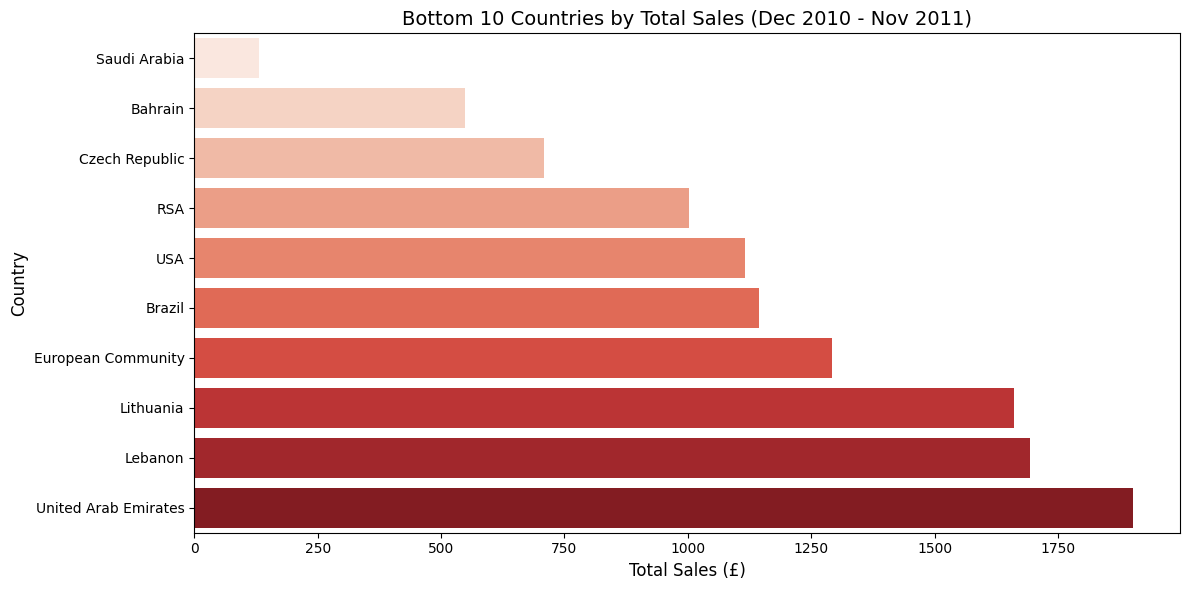


Bottom 10 Countries:
             Country  TotalSales
        Saudi Arabia      131.17
             Bahrain      548.40
      Czech Republic      707.72
                 RSA     1002.31
                 USA     1115.64
              Brazil     1143.60
  European Community     1291.75
           Lithuania     1661.06
             Lebanon     1693.88
United Arab Emirates     1902.28


In [97]:
# Bottom 10 Countries by Total Sales (excluding Dec 2011)
bottom_countries = df_clean[
    df_clean['YearMonth'] != '2011-12'
].groupby('Country')['TotalSales'].sum().reset_index()

bottom_countries = bottom_countries[bottom_countries['TotalSales'] > 0]
bottom_countries = bottom_countries.sort_values('TotalSales', ascending=True).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=bottom_countries,
            x='TotalSales',
            y='Country',
            hue='Country',
            palette='Reds',
            legend=False)

plt.title('Bottom 10 Countries by Total Sales (Dec 2010 - Nov 2011)', fontsize=14)
plt.xlabel('Total Sales (£)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

print("\nBottom 10 Countries:")
print(bottom_countries.to_string(index=False))

In [98]:
# Investigate bottom countries
bottom_country_list = bottom_countries['Country'].tolist()

investigation_countries = df_clean[
    df_clean['Country'].isin(bottom_country_list)
].groupby('Country').agg(
    Total_Transactions=('InvoiceNo', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_UnitPrice=('UnitPrice', 'mean'),
    Total_Sales=('TotalSales', 'sum')
).reset_index()

print(investigation_countries.to_string(index=False))

             Country  Total_Transactions  Total_Quantity  Avg_UnitPrice  Total_Sales
             Bahrain                  17             260       4.644118       548.40
              Brazil                  32             356       4.456250      1143.60
      Czech Republic                  30             592       2.938333       707.72
  European Community                  61             497       4.820492      1291.75
             Lebanon                  45             386       5.387556      1693.88
           Lithuania                  35             652       2.841143      1661.06
                 RSA                  57             351       4.352632      1002.31
        Saudi Arabia                  10              75       2.411000       131.17
                 USA                 291            1034       2.216426      1730.92
United Arab Emirates                  68             982       3.380735      1902.28


## Bottom 3 Products by Country (Top 10 Countries)

In [99]:
# Bottom 3 Products for Top 10 Countries
bottom_products_by_country = df_clean[
    (df_clean['YearMonth'] != '2011-12') &
    (~df_clean['Description'].isin(non_products))
].groupby(['Country', 'Description'])['TotalSales'].sum().reset_index()

# Only positive sales
bottom_products_by_country = bottom_products_by_country[
    bottom_products_by_country['TotalSales'] > 0
]

# Get bottom 3 products per country
bottom3_by_country = (bottom_products_by_country
    .sort_values('TotalSales', ascending=True)
    .groupby('Country')
    .head(3)
    .sort_values(['Country', 'TotalSales'], ascending=[True, True])
)

# Filter to top 10 countries only
bottom3_filtered = bottom3_by_country[
    bottom3_by_country['Country'].isin(top10_country_list)
].copy()

# Print formatted table
for country in top10_country_list:
    country_data = bottom3_filtered[bottom3_filtered['Country'] == country]
    print(f"\n{'='*50}")
    print(f"  {country}")
    print(f"{'='*50}")
    for _, row in country_data.iterrows():
        print(f"  {row['Description']:<45} £{row['TotalSales']:>10,.2f}")


  United Kingdom
  HEN HOUSE W CHICK IN NEST                     £      0.42
  WHITE BEADED GARLAND STRING 20LIGHT           £      0.80
  VINTAGE BLUE TINSEL REEL                      £      0.84

  Netherlands
  PACK OF 12 VINTAGE DOILY TISSUES              £      0.39
  PACK OF 12 SPACEBOY TISSUES                   £      0.39
  PACK OF 12 PAISLEY PARK TISSUES               £      0.39

  EIRE
  MAGIC DRAWING SLATE BAKE A CAKE               £      1.68
  MAGIC DRAWING SLATE DOLLY GIRL                £      1.68
  MAGIC DRAWING SLATE LEAP FROG                 £      1.68

  Germany
  SWALLOW SQUARE TISSUE BOX                     £      0.39
  CHERUB HEART DECORATION GOLD                  £      0.83
  INFLATABLE POLITICAL GLOBE                    £      0.85

  France
  BLUE EGG  SPOON                               £      0.36
  GLITTER HEART DECORATION                      £      0.39
  MIXED NUTS LIGHT GREEN BOWL                   £      0.42

  Australia
  PASTEL COLOUR HONEYCOMB

# **Key Findings & Business Recommendations**  
## Key Findings
**Sales Trend**
- Sales showed a general upward trend from Dec 2010 to Nov 2011,
  with dips in Q1 (Jan-Feb) and April, before a strong Q4 recovery
  peaking in November (£1.13M)
- December 2011 data is incomplete (1–9 Dec only) and excluded
  from trend analysis

**Pricing & Volume**
- November recorded the highest sales volume and the lowest Average
  Unit Price (£3.00), suggesting promotional pricing drove Q4 growth
- June 2011 saw the highest Average Unit Price (£4.70) but did not
  correspond to peak sales volume, indicating price increases alone
  do not drive revenue

**Top Products**
- REGENCY CAKESTAND 3 TIER was the best-selling product (£128,139),
  outperforming 2nd place by 40%
- Top products are predominantly home décor and gift items,
  indicating a clear customer preference

**Product Preference by Market**
- REGENCY CAKESTAND 3 TIER appears in top 3 across UK, EIRE,
  Germany, Switzerland and Spain, confirming its status as a hero product
- Netherlands and Belgium favour snack boxes and lunch boxes,
  suggesting a preference for practical everyday items
- France and Australia both favour RABBIT NIGHT LIGHT,
  indicating cross-market appeal for novelty lighting products

**Market Performance**
- United Kingdom dominates sales at 88% of total revenue (£6.45M)
- Netherlands, EIRE and Germany are the strongest international markets
- USA has 291 transactions but only £1,116 in revenue (Dec 2010 – Nov 2011), 
the lowest average order value among all markets

**Underperforming Areas**
- Saudi Arabia recorded the lowest sales (£131) with only 10 transactions
- Bottom products in Western Europe are mostly under £1.00,
  suggesting price alone does not drive purchase decisions
- Australia and Sweden's bottom products are priced £4-7,
  suggesting even relatively higher-priced items struggle to sell
  in these markets, possibly due to limited market penetration

---

## Business Recommendations
**1. Replicate Q4 Promotional Strategy in Q1**
November's success was driven by volume through lower pricing.
Recommend applying similar promotional pricing in Jan-April
to address the seasonal dip.

**2. Focus International Expansion on Europe**
Netherlands, EIRE and Germany show consistent demand.
Recommend increasing marketing budget for these three markets.

**3. Develop USA Upselling Strategy**
High transaction count (291) but low revenue suggests customers
are buying low-value items. Recommend introducing premium product
bundles targeted at US customers to increase average order value.

**4. Review Underperforming Products**
Bottom 10 products generated less than £1.25 each.
Recommend discontinuing or bundling these with popular products
to reduce inventory costs.

**5. Leverage Hero Products Globally**
REGENCY CAKESTAND 3 TIER sells well across UK, EIRE, Germany and Spain.
Recommend promoting this product in markets where it has not yet
appeared, particularly Netherlands and France.

## Export for SQL Analysis

The cleaned dataset is exported to CSV, allowing the same data
to be analysed using SQL in `sql_analysis.ipynb`.

In [100]:
# Export cleaned data for SQL analysis
df_clean.to_csv('data/data_clean.csv', index=False)
print(f"Exported {len(df_clean)} rows to data/data_clean.csv")

Exported 401560 rows to data/data_clean.csv
